# Experiment 9 – Evaluate and Interpret Machine Learning Models using Validation and Explainability Techniques

**Dataset:** Pima Indians Diabetes Dataset

**Platform:** Google Colab

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, brier_score_loss, classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve
import shap
from lime.lime_tabular import LimeTabularExplainer
import warnings
warnings.filterwarnings("ignore")


/opt/pyvenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Dataset

In [3]:
columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

# In Google Colab, upload diabetes.csv if it is not already present.
import os
if os.path.exists("diabetes.csv"):
    df = pd.read_csv("diabetes.csv")
else:
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    df = pd.read_csv(url, names=columns)

if list(df.columns) != columns:
    df.columns = columns

print("=" * 70)
print("PIMA INDIANS DIABETES DATASET")
print("=" * 70)
print("\nDataset Shape:")
print(df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nDataset Information:")
df.info()
print("\nClass Distribution:")
print(df["Outcome"].value_counts())
print("\nStatistical Summary:")
print(df.describe())


PIMA INDIANS DIABETES DATASET

Dataset Shape:
(768, 9)

First 5 Rows:
   Pregnancies  Glucose  BloodPressure  ...  DiabetesPedigreeFunction  Age  Outcome
0            6      148             72  ...                     0.627   50        1
1            1       85             66  ...                     0.351   31        0
2            8      183             64  ...                     0.672   32        1
3            1       89             66  ...                     0.167   21        0
4            0      137             40  ...                     2.288   33        1

[5 rows x 9 columns]

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3 

In [4]:
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[zero_as_missing] = df[zero_as_missing].replace(0, np.nan)

print("\nMissing Values After Preprocessing:")
print(df.isnull().sum())

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("\nTraining Set Size:", X_train.shape)
print("Testing Set Size:", X_test.shape)

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000))
])



Missing Values After Preprocessing:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Training Set Size: (614, 8)
Testing Set Size: (154, 8)


## 2. 5-Fold Cross-Validation

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"accuracy": "accuracy", "f1": "f1"}

cv_results = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring)
cv_accuracy = cv_results["test_accuracy"]
cv_f1 = cv_results["test_f1"]

print("\n" + "=" * 70)
print("5-FOLD CROSS-VALIDATION")
print("=" * 70)
print("\nAccuracy:")
for i, score in enumerate(cv_accuracy, 1):
    print("Fold", i, ":", round(score, 4))
print("\nF1 Score:")
for i, score in enumerate(cv_f1, 1):
    print("Fold", i, ":", round(score, 4))
print("\nMean Accuracy:", round(cv_accuracy.mean(), 4))
print("Accuracy Std:", round(cv_accuracy.std(), 4))
print("\nMean F1 Score:", round(cv_f1.mean(), 4))
print("F1 Std:", round(cv_f1.std(), 4))



5-FOLD CROSS-VALIDATION

Accuracy:
Fold 1 : 0.7886
Fold 2 : 0.7886
Fold 3 : 0.8211
Fold 4 : 0.7805
Fold 5 : 0.7623

F1 Score:
Fold 1 : 0.6389
Fold 2 : 0.6667
Fold 3 : 0.6944
Fold 4 : 0.6494
Fold 5 : 0.6234

Mean Accuracy: 0.7882
Accuracy Std: 0.0191

Mean F1 Score: 0.6545
F1 Std: 0.0244


## 3. Test Set Performance


TEST SET PERFORMANCE

Accuracy: 0.7078
F1 Score: 0.5455

Classification Report:
              precision    recall  f1-score   support

Non-diabetic       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


Confusion Matrix:
[[82 18]
 [27 27]]


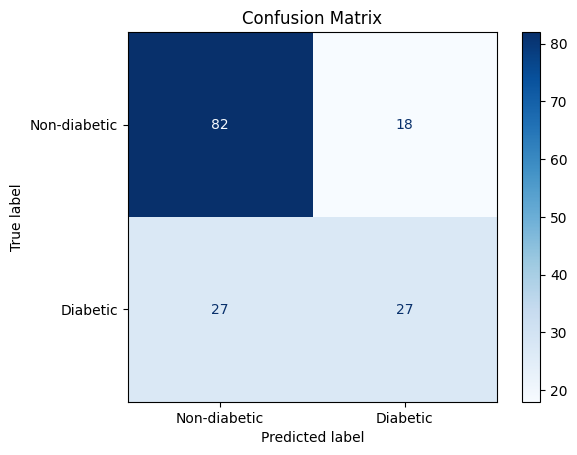

In [6]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n" + "=" * 70)
print("TEST SET PERFORMANCE")
print("=" * 70)
print("\nAccuracy:", round(accuracy, 4))
print("F1 Score:", round(f1, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-diabetic", "Diabetic"]))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-diabetic", "Diabetic"]
).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


## 4. Brier Score and Calibration Curve


Brier Score: 0.1754


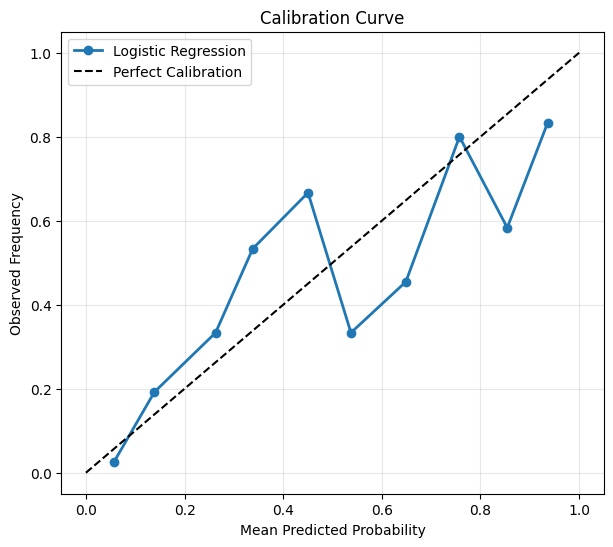

In [7]:
brier = brier_score_loss(y_test, y_prob)
print("\nBrier Score:", round(brier, 4))

prob_true, prob_pred = calibration_curve(
    y_test, y_prob, n_bins=10, strategy="uniform"
)

plt.figure(figsize=(7, 6))
plt.plot(prob_pred, prob_true, marker="o", linewidth=2, label="Logistic Regression")
plt.plot([0, 1], [0, 1], "--", color="black", label="Perfect Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 5. SHAP Explainability

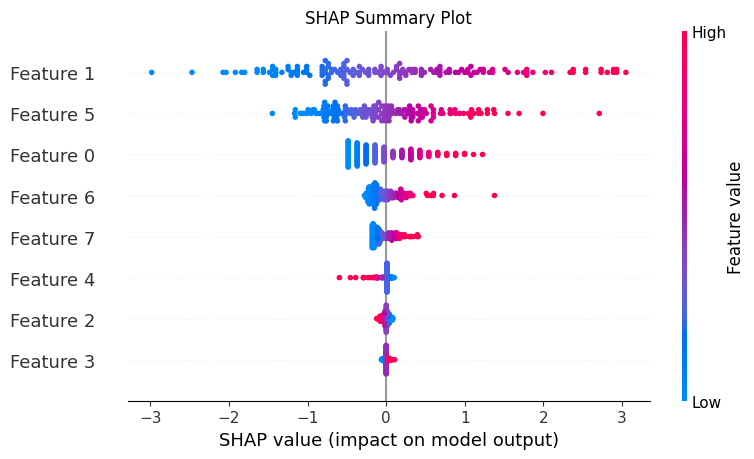


SHAP Feature Importance:
                 Feature  Mean Absolute SHAP
                 Glucose            1.015598
                     BMI            0.566222
             Pregnancies            0.341236
DiabetesPedigreeFunction            0.173953
                     Age            0.126328
                 Insulin            0.046597
           BloodPressure            0.031183
           SkinThickness            0.017992


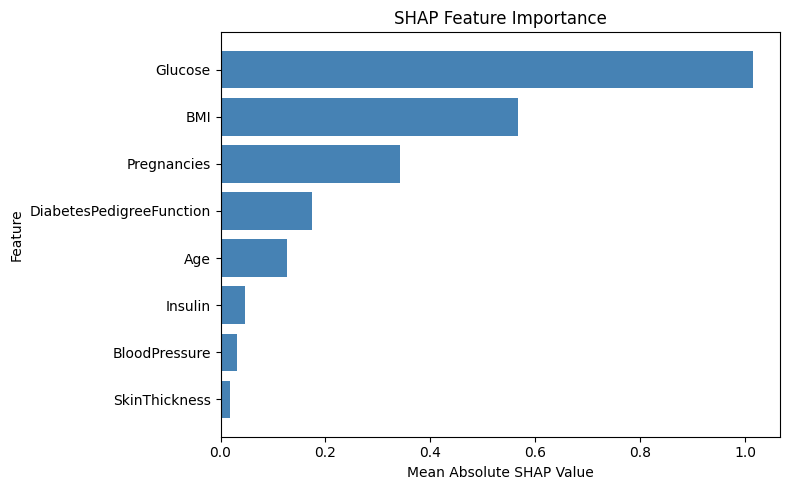

In [8]:
imputer = pipeline.named_steps["imputer"]
scaler = pipeline.named_steps["scaler"]
model = pipeline.named_steps["classifier"]

X_train_imputed = imputer.transform(X_train)
X_test_imputed = imputer.transform(X_test)
X_train_scaled = scaler.transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

explainer = shap.LinearExplainer(model, X_train_scaled)
shap_values = explainer(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled_df, show=False)
plt.title("SHAP Summary Plot")
plt.tight_layout()
plt.show()

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean Absolute SHAP": mean_abs_shap
}).sort_values("Mean Absolute SHAP", ascending=False)

print("\nSHAP Feature Importance:")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.barh(feature_importance["Feature"], feature_importance["Mean Absolute SHAP"], color="steelblue")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("SHAP Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 6. Individual Patient Prediction


INDIVIDUAL PATIENT PREDICTION

Patient Features:
    Pregnancies  Glucose  BloodPressure  ...   BMI  DiabetesPedigreeFunction  Age
44            7    159.0           64.0  ...  27.4                     0.294   40

[1 rows x 8 columns]

Actual Outcome: 0
Predicted Outcome: 1
Predicted Probability: 0.6097

Generating SHAP individual explanation...


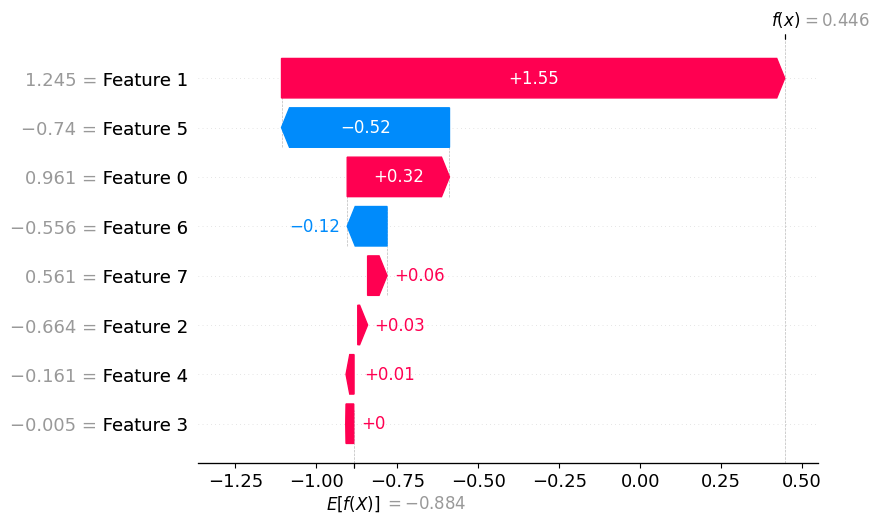

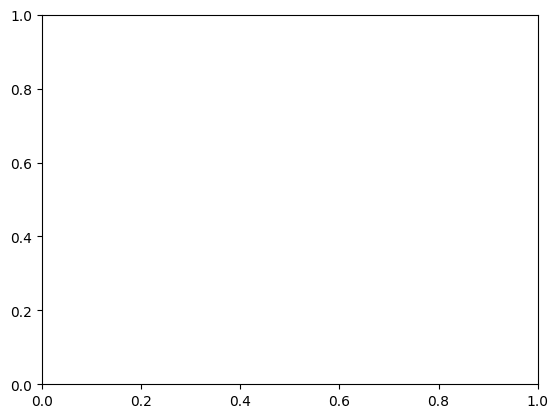

In [9]:
sample_index = 0

print("\n" + "=" * 70)
print("INDIVIDUAL PATIENT PREDICTION")
print("=" * 70)
print("\nPatient Features:")
print(X_test.iloc[[sample_index]])
print("\nActual Outcome:", y_test.iloc[sample_index])
print("Predicted Outcome:", y_pred[sample_index])
print("Predicted Probability:", round(y_prob[sample_index], 4))

print("\nGenerating SHAP individual explanation...")
shap.plots.waterfall(shap_values[sample_index], max_display=10)
plt.show()


## 7. LIME Explainability

In [10]:
lime_explainer = LimeTabularExplainer(
    X_train_scaled,
    feature_names=X.columns.tolist(),
    class_names=["Non-diabetic", "Diabetic"],
    mode="classification",
    random_state=42
)

lime_exp = lime_explainer.explain_instance(
    X_test_scaled[sample_index],
    model.predict_proba,
    num_features=len(X.columns)
)

print("\nLIME Explanation:")
for feature, weight in lime_exp.as_list():
    print(feature, ":", round(weight, 4))



LIME Explanation:
Glucose : 0.2662
BMI : 0.1547
Pregnancies : 0.0842
DiabetesPedigreeFunction : 0.0528
Age : 0.0332
Insulin : -0.0148
BloodPressure : -0.0099
SkinThickness : 0.0065


## 8. Final Results

In [11]:
results = pd.DataFrame({
    "Metric": [
        "5-Fold Mean Accuracy", "5-Fold Accuracy Std",
        "5-Fold Mean F1", "5-Fold F1 Std",
        "Test Accuracy", "Test F1", "Brier Score"
    ],
    "Value": [
        cv_accuracy.mean(), cv_accuracy.std(),
        cv_f1.mean(), cv_f1.std(), accuracy, f1, brier
    ]
})

print("\n" + "=" * 70)
print("FINAL RESULTS")
print("=" * 70)
print(results.to_string(index=False))

print("\n" + "=" * 70)
print("TOP 5 IMPORTANT FEATURES")
print("=" * 70)
for rank, (_, row) in enumerate(feature_importance.head(5).iterrows(), 1):
    print(rank, ".", row["Feature"], "-> SHAP:", round(row["Mean Absolute SHAP"], 4))

print("\n" + "=" * 70)
print("CONCLUSION")
print("=" * 70)
print("The Pima Indians Diabetes Dataset was used to train a Logistic Regression classification model. The model was evaluated using 5-fold stratified cross-validation, accuracy, F1-score, Brier Score, and a calibration curve. SHAP was used to identify the features that had the greatest influence on model predictions, and LIME was used to provide a local explanation for an individual patient prediction.")



FINAL RESULTS
              Metric    Value
5-Fold Mean Accuracy 0.788231
 5-Fold Accuracy Std 0.019057
      5-Fold Mean F1 0.654545
       5-Fold F1 Std 0.024423
       Test Accuracy 0.707792
             Test F1 0.545455
         Brier Score 0.175420

TOP 5 IMPORTANT FEATURES
1 . Glucose -> SHAP: 1.0156
2 . BMI -> SHAP: 0.5662
3 . Pregnancies -> SHAP: 0.3412
4 . DiabetesPedigreeFunction -> SHAP: 0.174
5 . Age -> SHAP: 0.1263

CONCLUSION
The Pima Indians Diabetes Dataset was used to train a Logistic Regression classification model. The model was evaluated using 5-fold stratified cross-validation, accuracy, F1-score, Brier Score, and a calibration curve. SHAP was used to identify the features that had the greatest influence on model predictions, and LIME was used to provide a local explanation for an individual patient prediction.
